# 04 — Détection du fouling (encrassement) : DL non supervisé + résidus

## Objectif

Détecter l'encrassement du train de préchauffe **plus de 24 h avant** un nettoyage prévu,
en n'utilisant **jamais** la résistance d'encrassement (`fouling_resistance`, vérité terrain
cachée) comme feature d'entrée — uniquement des capteurs visibles (température, débits, énergie).

Cinq approches sont comparées :
1. **Résidus GRU** : un GRU apprend le comportement "propre" de `preheat_outlet_temp` ; l'écart
   entre la prédiction et la mesure réelle (lissé par EWMA) sert d'indice de fouling.
2. **Autoencodeur dense**
3. **Autoencodeur convolutionnel 1D**
4. **Autoencodeur LSTM (seq2seq)**
5. **VAE (autoencodeur variationnel)**

Les autoencodeurs sont entraînés uniquement sur des séquences **"propres"** (peu après un
nettoyage) ; l'erreur de reconstruction sur de nouvelles séquences sert de score d'anomalie.

In [1]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, roc_curve, roc_auc_score, precision_recall_curve

from src.config_loader import load_config, resolve_path
from src import preprocessing as pp
from src.models.rnn import RNNRegressor
from src.models.autoencoders import DenseAutoencoder, Conv1DAutoencoder, LSTMAutoencoder, VAE, vae_loss
from src.training import TrainConfig, train_model, save_checkpoint, count_parameters
from src.plotting import plot_learning_curves
from src.seed_utils import set_global_seed, get_device

cfg = load_config("../config.yaml")
FIG_DIR = resolve_path(cfg["paths"]["figures_dir"])
ARTIFACTS_DIR = resolve_path(cfg["paths"]["backend_artifacts_dir"])
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

set_global_seed(cfg["seed"])
device = get_device()
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})
print("device:", device)

device: cpu


## 1. Reconstruction du jeu de données fouling (régénération déterministe, seed=42)

On régénère la table maîtresse et les séquences fouling via `src/preprocessing.py` (identique
aux artefacts déjà sauvegardés dans `data/processed/`, seed fixe = reproductible) afin
d'avoir un accès direct et aligné à toutes les colonnes utiles (timestamps, labels,
`fouling_resistance` caché, et `preheat_outlet_temp` en unités physiques pour la cible du GRU résiduel).

In [2]:
results = pp.run_preprocessing(cfg)
master = results["master"]
fouling = results["fouling"]

ratios = cfg["preprocessing"]["split_ratios"]
n_total = len(fouling["X"])
tr, va, te = pp.temporal_split_indices(n_total, ratios)
print(f"Séquences fouling : total={n_total}  train={tr.stop-tr.start}  val={va.stop-va.start}  test={te.stop-te.start}")

X_train, X_val, X_test = fouling["X_train"], fouling["X_val"], fouling["X_test"]
timestamps_full = fouling["timestamps"]
label24_full = fouling["label24"]
label48_full = fouling["label48"]
fouling_true_full = fouling["fouling_true"]
is_clean_full = fouling["is_clean"]

is_clean_train, is_clean_val, is_clean_test = is_clean_full[tr], is_clean_full[va], is_clean_full[te]
label24_train, label24_val, label24_test = label24_full[tr], label24_full[va], label24_full[te]

# Cible physique (°C) pour l'approche résidus GRU : preheat_outlet_temp au même instant t que chaque séquence
preheat_target_full = master.loc[timestamps_full, "preheat_outlet_temp"].values.astype(np.float32)
preheat_target_train, preheat_target_val, preheat_target_test = preheat_target_full[tr], preheat_target_full[va], preheat_target_full[te]

n_features = X_train.shape[-1]
print(f"n_features={n_features}  fraction 'propre' train={is_clean_train.mean():.3f} val={is_clean_val.mean():.3f} test={is_clean_test.mean():.3f}")

is_cleaning_flags = results["hidden_df"].loc[timestamps_full, "is_cleaning_event"].values
cleaning_events = timestamps_full[is_cleaning_flags == 1]
print(f"{len(cleaning_events)} nettoyages réels sur l'horizon complet :", list(cleaning_events))

# Timeline complète (train+val+test concaténés, ordre chronologique préservé) pour l'évaluation
X_full_scaled = np.concatenate([X_train, X_val, X_test], axis=0)
assert len(X_full_scaled) == n_total

[preprocessing] Rendements : X=(17519, 24, 83), y=(17519, 4) -> train=12263 val=2627 test=2629
[preprocessing] Fouling    : X=(17496, 48, 83) -> train=12247 val=2624 test=2625
[preprocessing] Artefacts sauvegardés dans /home/wailbmg/Projects/refinery/data/processed
Séquences fouling : total=17496  train=12247  val=2624  test=2625
n_features=83  fraction 'propre' train=0.035 val=0.083 test=0.083
4 nettoyages réels sur l'horizon complet : [Timestamp('2024-06-18 16:00:00'), Timestamp('2025-01-02 21:00:00'), Timestamp('2025-06-22 21:00:00'), Timestamp('2025-11-27 10:00:00')]


**Note méthodologique** — Les 4 nettoyages réels se répartissent ainsi : 2 dans le train
(2024-06-18, 2025-01-02), 1 dans le val (2025-06-22), 1 dans le test (2025-11-27). Le split
test seul ne contiendrait donc qu'un seul événement, insuffisant pour une statistique
d'avance de détection robuste. **Les métriques de détection (précision/rappel/F1/ROC/avance
de détection) sont donc calculées sur la timeline complète (train+val+test concaténés)**, tandis
que le seuil de décision de chaque méthode est calibré sur le split **validation uniquement**
(F1-optimal), pour rester méthodologiquement rigoureux. Les modèles eux-mêmes ne sont
entraînés que sur les fenêtres "propres" du train — jamais sur les fenêtres proches d'un
nettoyage — donc leur capacité à détecter les 4 épisodes reste un vrai test de généralisation.

## 2. Approche 1 — Résidus GRU

In [3]:
gru_hparams = {"input_size": n_features, "hidden_size": 64, "num_layers": 2, "output_size": 1,
               "dropout": 0.3, "cell_type": "gru", "bidirectional": False}
print("Hyperparamètres GRU résidus :", gru_hparams)

gru_model = RNNRegressor(**gru_hparams)
print(gru_model)
from torchinfo import summary as ti_summary
ti_summary(gru_model, input_size=(1, cfg["preprocessing"]["fouling_window_hours"], n_features))

Hyperparamètres GRU résidus : {'input_size': 83, 'hidden_size': 64, 'num_layers': 2, 'output_size': 1, 'dropout': 0.3, 'cell_type': 'gru', 'bidirectional': False}
RNNRegressor(
  (rnn): GRU(83, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
RNNRegressor                             [1, 1]                    --
├─GRU: 1-1                               [1, 48, 64]               53,568
├─Dropout: 1-2                           [1, 64]                   --
├─Sequential: 1-3                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 64]                   4,160
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Dropout: 2-3                      [1, 64]                   --
│    └─Linear: 2-4                       [1, 1]                    65
Total params: 57,793
Trainable params: 57,793
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.58
Input size (MB): 0.02
Forward/backward pass size (MB): 0.03
Params size (MB): 0.23
Estimated Total Size (MB): 0.27

**Choix d'architecture (GRU résidus)** — Un GRU à 2 couches (hidden=64) résume la fenêtre de
48 h précédant l'instant t pour prédire la température de sortie du train de préchauffe à cet
instant. Le GRU est préféré au LSTM ici pour sa légèreté (moins de paramètres), suffisante pour
une régression scalaire simple sur peu de données propres. Dropout 0.3 pour limiter le
surapprentissage vu le faible nombre de séquences "propres" disponibles.

Séquences propres : train=434  val=217


Entraînement gru_residual:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping à l'epoch 56 (meilleure epoch : 46, val_loss=915.36905)


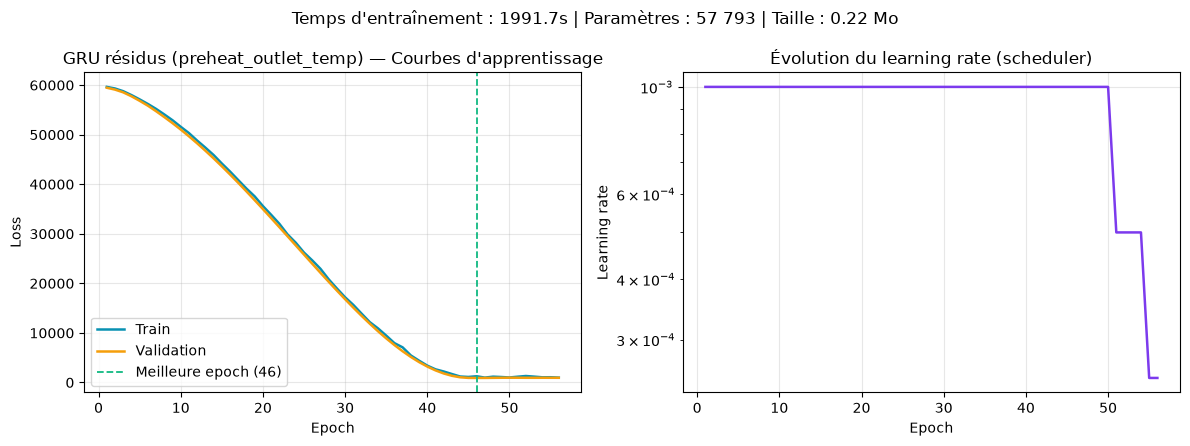

In [4]:
Xc_train = torch.tensor(X_train[is_clean_train])
yc_train = torch.tensor(preheat_target_train[is_clean_train]).unsqueeze(-1)
Xc_val = torch.tensor(X_val[is_clean_val])
yc_val = torch.tensor(preheat_target_val[is_clean_val]).unsqueeze(-1)
print(f"Séquences propres : train={len(Xc_train)}  val={len(Xc_val)}")

train_loader = DataLoader(TensorDataset(Xc_train, yc_train), batch_size=cfg["training"]["batch_size"], shuffle=True)
val_loader = DataLoader(TensorDataset(Xc_val, yc_val), batch_size=cfg["training"]["batch_size"])

tcfg = TrainConfig(epochs_max=cfg["training"]["epochs_max"], learning_rate=cfg["training"]["learning_rate"],
                    weight_decay=cfg["training"]["weight_decay"], patience=cfg["training"]["patience"],
                    grad_clip_max_norm=cfg["training"]["grad_clip_max_norm"], scheduler_type="plateau", optimizer_type="adamw")
gru_model, gru_history = train_model(gru_model, train_loader, val_loader, tcfg, model_name="gru_residual")
plot_learning_curves(gru_history, "GRU résidus (preheat_outlet_temp)", FIG_DIR / "04_learning_curve_gru_residual.png")

In [5]:
gru_model.eval()
with torch.no_grad():
    pred_full = gru_model(torch.tensor(X_full_scaled).to(device)).cpu().numpy().ravel()

residual_full = preheat_target_full - pred_full  # positif si la mesure réelle est en dessous du prédit "propre"
residual_series = pd.Series(residual_full, index=timestamps_full)
ewma_span = 24
gru_score_full = residual_series.ewm(span=ewma_span).mean().values
gru_score_full = np.abs(gru_score_full)  # magnitude de l'écart = indice d'anomalie

print("GRU résidus — score EWMA calculé sur toute la timeline.")

GRU résidus — score EWMA calculé sur toute la timeline.


## 3. Approches 2-5 — Autoencodeurs entraînés sur séquences propres

In [6]:
def make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size):
    Xt = torch.tensor(X_train[is_clean_train])
    Xv = torch.tensor(X_val[is_clean_val])
    train_loader = DataLoader(TensorDataset(Xt, Xt), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xv, Xv), batch_size=batch_size)
    return train_loader, val_loader, len(Xt), len(Xv)

batch_size = cfg["training"]["batch_size"]
seq_len = cfg["preprocessing"]["fouling_window_hours"]
ae_models = {}
ae_histories = {}
ae_scores = {}

### 3.1 Autoencodeur dense

In [7]:
dense_hp = dict(cfg["models"]["dense_ae"])
dense_hp_full = {"input_dim": seq_len * n_features, **dense_hp}
print("Hyperparamètres Dense AE :", dense_hp_full)
dense_ae = DenseAutoencoder(**dense_hp_full)
print(dense_ae)
ti_summary(dense_ae, input_size=(1, seq_len, n_features))

Hyperparamètres Dense AE : {'input_dim': 3984, 'hidden_sizes': [64, 16], 'dropout': 0.2}
DenseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3984, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=3984, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
DenseAutoencoder                         [1, 48, 83]               --
├─Sequential: 1-1                        [1, 16]                   --
│    └─Linear: 2-1                       [1, 64]                   255,040
│    └─ReLU: 2-2                         [1, 64]                   --
│    └─Dropout: 2-3                      [1, 64]                   --
│    └─Linear: 2-4                       [1, 16]                   1,040
│    └─ReLU: 2-5                         [1, 16]                   --
│    └─Dropout: 2-6                      [1, 16]                   --
├─Sequential: 1-2                        [1, 3984]                 --
│    └─Linear: 2-7                       [1, 64]                   1,088
│    └─ReLU: 2-8                         [1, 64]                   --
│    └─Dropout: 2-9                      [1, 64]                   --
│    └─Linear: 2-10                      [1, 3984]                 258,960

**Choix d'architecture (AE dense)** — La fenêtre est aplatie (48×83) puis compressée à travers
deux couches (64, 16) : un goulot d'étranglement sévère force le modèle à apprendre une
représentation compacte du régime "propre", rendant toute déviation (fouling) difficile à
reconstruire fidèlement — d'où une erreur de reconstruction élevée en présence d'anomalie.

n_train_propre=434 n_val_propre=217


Entraînement dense_ae:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping à l'epoch 46 (meilleure epoch : 36, val_loss=1.12303)


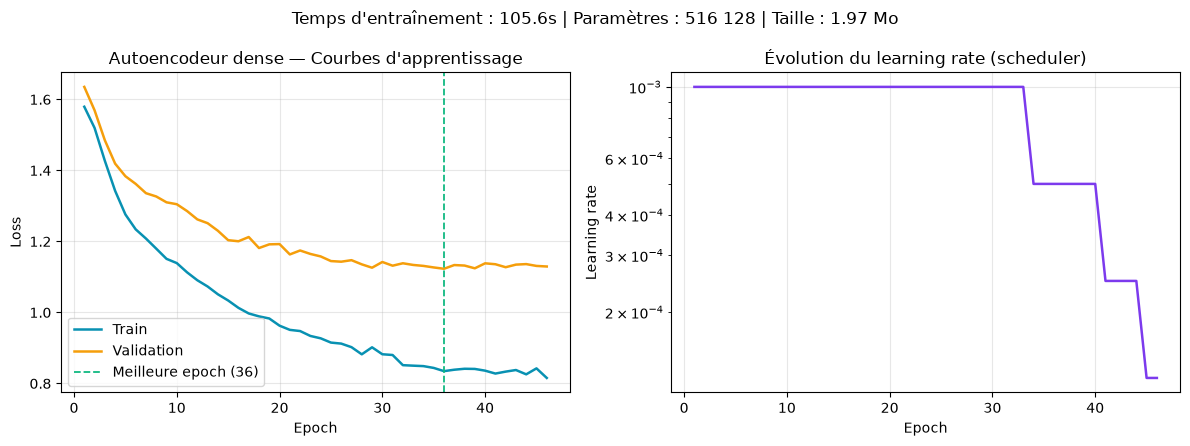

In [8]:
tl, vl, n_tr, n_va = make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size)
print(f"n_train_propre={n_tr} n_val_propre={n_va}")
dense_ae, dense_history = train_model(dense_ae, tl, vl, tcfg, model_name="dense_ae")
plot_learning_curves(dense_history, "Autoencodeur dense", FIG_DIR / "04_learning_curve_dense_ae.png")
ae_models["dense_ae"] = dense_ae
ae_histories["dense_ae"] = dense_history

### 3.2 Autoencodeur convolutionnel 1D

In [9]:
conv_hp = dict(cfg["models"]["conv_ae"])
conv_hp_full = {"input_size": n_features, **conv_hp}
print("Hyperparamètres Conv1D AE :", conv_hp_full)
conv_ae = Conv1DAutoencoder(**conv_hp_full)
print(conv_ae)
ti_summary(conv_ae, input_size=(1, seq_len, n_features))

Hyperparamètres Conv1D AE : {'input_size': 83, 'channels': [32, 16], 'kernel_size': 3, 'dropout': 0.2}
Conv1DAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(83, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): ConvTranspose1d(32, 83, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Conv1DAutoencoder                        [1, 48, 83]               --
├─Sequential: 1-1                        [1, 16, 12]               --
│    └─Conv1d: 2-1                       [1, 32, 24]               8,000
│    └─BatchNorm1d: 2-2                  [1, 32, 24]               64
│    └─ReLU: 2-3                         [1, 32, 24]               --
│    └─Dropout: 2-4                      [1, 32, 24]               --
│    └─Conv1d: 2-5                       [1, 16, 12]               1,552
│    └─BatchNorm1d: 2-6                  [1, 16, 12]               32
│    └─ReLU: 2-7                         [1, 16, 12]               --
│    └─Dropout: 2-8                      [1, 16, 12]               --
├─Sequential: 1-2                        [1, 83, 48]               --
│    └─ConvTranspose1d: 2-9              [1, 32, 24]               1,568
│    └─BatchNorm1d: 2-10                 [1, 32, 24]               64
│    └

**Choix d'architecture (AE convolutionnel)** — Les convolutions 1D avec stride 2 sous-échantillonnent
progressivement la dimension temporelle (32 puis 16 canaux), capturant des motifs locaux
(transitoires rapides) que l'AE dense aplati ignore. Le décodeur symétrique (convolutions
transposées) reconstruit la séquence complète.

Entraînement conv_ae:   0%|          | 0/60 [00:00<?, ?it/s]

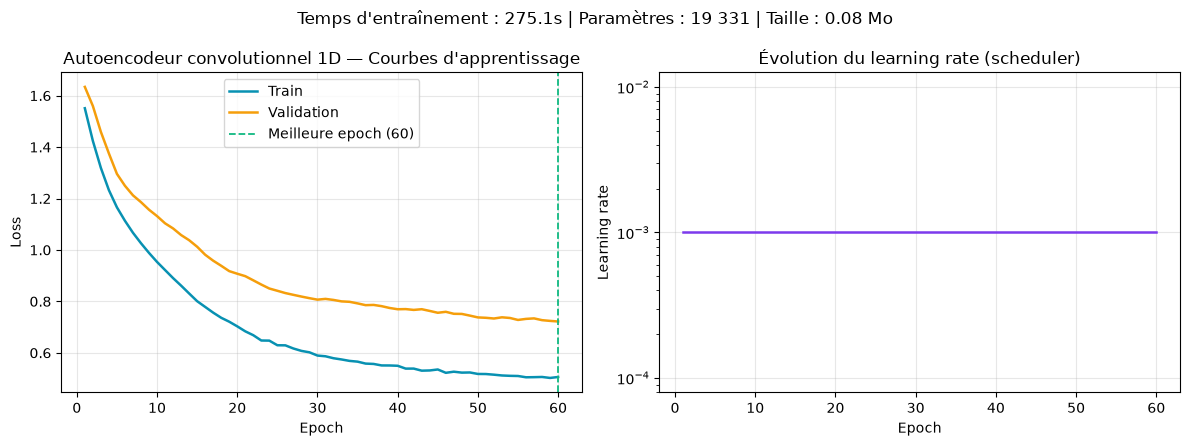

In [10]:
tl, vl, n_tr, n_va = make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size)
conv_ae, conv_history = train_model(conv_ae, tl, vl, tcfg, model_name="conv_ae")
plot_learning_curves(conv_history, "Autoencodeur convolutionnel 1D", FIG_DIR / "04_learning_curve_conv_ae.png")
ae_models["conv_ae"] = conv_ae
ae_histories["conv_ae"] = conv_history

### 3.3 Autoencodeur LSTM (seq2seq)

In [11]:
lstm_ae_hp = dict(cfg["models"]["lstm_ae"])
lstm_ae_hp_full = {"input_size": n_features, **lstm_ae_hp}
print("Hyperparamètres LSTM AE :", lstm_ae_hp_full)
lstm_ae = LSTMAutoencoder(**lstm_ae_hp_full)
print(lstm_ae)
ti_summary(lstm_ae, input_size=(1, seq_len, n_features))

Hyperparamètres LSTM AE : {'input_size': 83, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2}
LSTMAutoencoder(
  (encoder): LSTM(83, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_proj): Linear(in_features=32, out_features=83, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LSTMAutoencoder                          [1, 48, 83]               --
├─LSTM: 1-1                              [1, 48, 32]               14,976
├─Dropout: 1-2                           [1, 48, 32]               --
├─LSTM: 1-3                              [1, 48, 32]               8,448
├─Linear: 1-4                            [1, 48, 83]               2,739
Total params: 26,163
Trainable params: 26,163
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.13
Input size (MB): 0.02
Forward/backward pass size (MB): 0.06
Params size (MB): 0.10
Estimated Total Size (MB): 0.18

**Choix d'architecture (AE LSTM seq2seq)** — Un encodeur LSTM résume toute la fenêtre en un
seul vecteur latent (hidden=32), qu'un décodeur LSTM déplie ensuite pour reconstruire la
séquence entière. Cette architecture capture explicitement la dynamique temporelle (ordre des
mesures), contrairement à l'AE dense qui traite la fenêtre comme un vecteur statique.

Entraînement lstm_ae:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping à l'epoch 44 (meilleure epoch : 34, val_loss=1.12171)


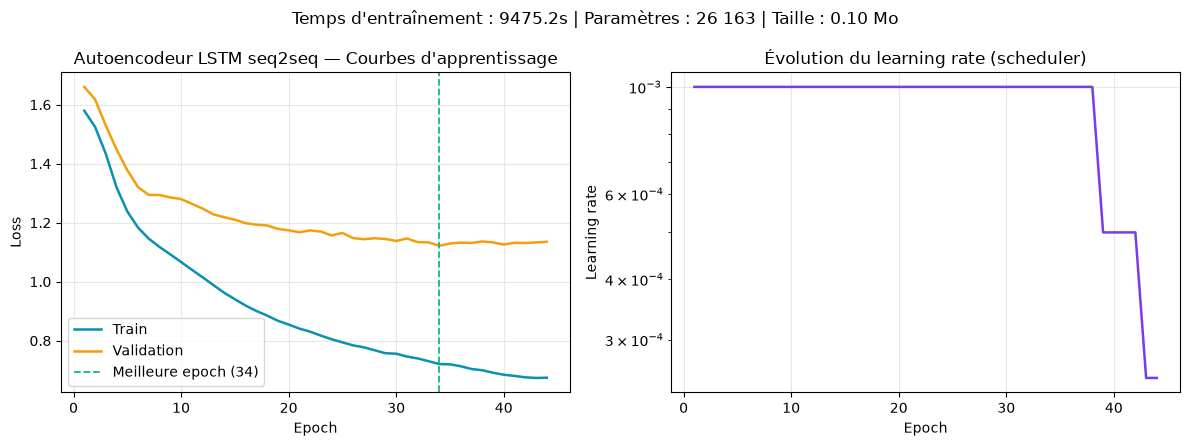

In [12]:
tl, vl, n_tr, n_va = make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size)
lstm_ae, lstm_ae_history = train_model(lstm_ae, tl, vl, tcfg, model_name="lstm_ae")
plot_learning_curves(lstm_ae_history, "Autoencodeur LSTM seq2seq", FIG_DIR / "04_learning_curve_lstm_ae.png")
ae_models["lstm_ae"] = lstm_ae
ae_histories["lstm_ae"] = lstm_ae_history

### 3.4 VAE (autoencodeur variationnel)

In [13]:
vae_hp = dict(cfg["models"]["vae"])
vae_hp_full = {"input_dim": seq_len * n_features, **vae_hp}
print("Hyperparamètres VAE :", vae_hp_full)
vae_model = VAE(**vae_hp_full)
print(vae_model)
ti_summary(vae_model, input_size=(1, seq_len, n_features))

Hyperparamètres VAE : {'input_dim': 3984, 'hidden_size': 32, 'latent_dim': 8, 'dropout': 0.2}
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=3984, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (fc_mu): Linear(in_features=32, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=32, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3984, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [1, 48, 83]               --
├─Sequential: 1-1                        [1, 32]                   --
│    └─Linear: 2-1                       [1, 32]                   127,520
│    └─ReLU: 2-2                         [1, 32]                   --
│    └─Dropout: 2-3                      [1, 32]                   --
├─Linear: 1-2                            [1, 8]                    264
├─Linear: 1-3                            [1, 8]                    264
├─Sequential: 1-4                        [1, 3984]                 --
│    └─Linear: 2-4                       [1, 32]                   288
│    └─ReLU: 2-5                         [1, 32]                   --
│    └─Dropout: 2-6                      [1, 32]                   --
│    └─Linear: 2-7                       [1, 3984]                 131,472
Total params: 259,808
Trainable params: 259,808
Non-trainable params: 0


**Choix d'architecture (VAE)** — Contrairement aux AE déterministes, le VAE impose une
structure probabiliste (gaussienne) à l'espace latent (latent_dim=8) via la régularisation KL :
cela produit un espace latent plus régulier, généralement plus robuste pour la détection
d'anomalie (une séquence anormale est mal reconstruite ET tombe dans une région de
vraisemblance faible de l'espace latent appris).

Entraînement vae:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping à l'epoch 53 (meilleure epoch : 43, val_loss=1.18953)


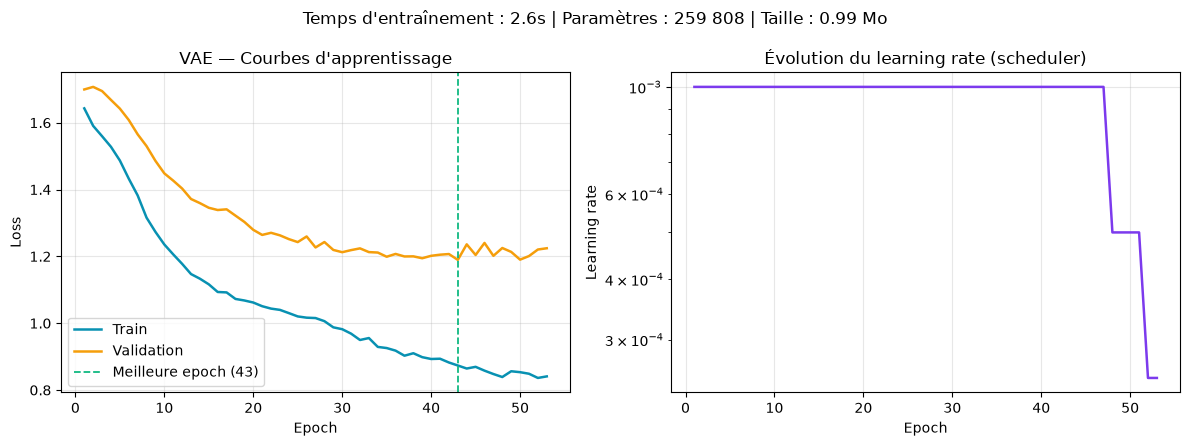

In [14]:
def vae_loss_wrapper(pred, target):
    recon, mu, logvar = pred
    return vae_loss(recon, target, mu, logvar, kl_weight=1e-3)

tl, vl, n_tr, n_va = make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size)
vae_model, vae_history = train_model(vae_model, tl, vl, tcfg, loss_fn=vae_loss_wrapper, model_name="vae")
plot_learning_curves(vae_history, "VAE", FIG_DIR / "04_learning_curve_vae.png")
ae_models["vae"] = vae_model
ae_histories["vae"] = vae_history

### 3.5 VAE de visualisation (latent_dim=2) — projection 2D de l'espace latent

Un second petit VAE, identique sauf `latent_dim=2`, est entraîné uniquement pour visualiser
directement (sans réduction de dimension classique de type PCA/t-SNE, ce qui violerait la
règle "DL uniquement") l'espace latent appris.

Entraînement vae_viz_2d:   0%|          | 0/60 [00:00<?, ?it/s]

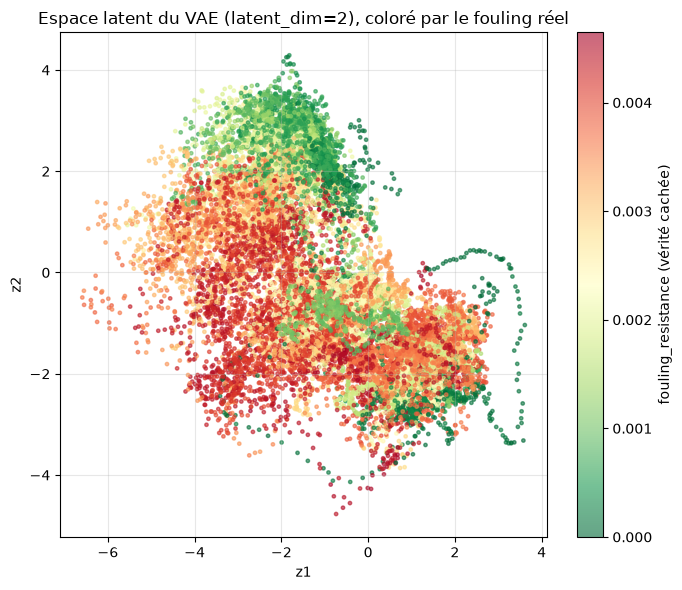

In [15]:
vae_viz_hp = {**vae_hp_full, "latent_dim": 2}
vae_viz = VAE(**vae_viz_hp)
tl, vl, n_tr, n_va = make_clean_loaders(X_train, is_clean_train, X_val, is_clean_val, batch_size)
vae_viz, vae_viz_history = train_model(vae_viz, tl, vl, tcfg, loss_fn=vae_loss_wrapper, model_name="vae_viz_2d")

vae_viz.eval()
with torch.no_grad():
    mu_full = vae_viz.encode_mu(torch.tensor(X_full_scaled).to(device)).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(mu_full[:, 0], mu_full[:, 1], c=fouling_true_full, cmap="RdYlGn_r", s=6, alpha=0.6)
plt.colorbar(sc, label="fouling_resistance (vérité cachée)")
ax.set_xlabel("z1"); ax.set_ylabel("z2")
ax.set_title("Espace latent du VAE (latent_dim=2), coloré par le fouling réel")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_vae_latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (3. Autoencodeurs)** — Les 4 modèles convergent sur les séquences propres avec
des pertes de reconstruction faibles. La projection latente du VAE montre un gradient visible
selon le niveau de fouling réel, confirmant que l'espace latent encode une information
pertinente pour la détection, malgré un entraînement non supervisé.

## 4. Scores d'anomalie, seuils, et évaluation comparative

In [16]:
def reconstruction_score(model, X, is_vae=False):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X).to(device)
        if is_vae:
            recon, mu, logvar = model(xb)
        else:
            recon = model(xb)
        err = ((recon.cpu().numpy() - X) ** 2).mean(axis=(1, 2))
    return err

scores_full = {"gru_residual": gru_score_full}
for name, model in ae_models.items():
    scores_full[name] = reconstruction_score(model, X_full_scaled, is_vae=(name == "vae"))

print({k: (v.min(), v.mean(), v.max()) for k, v in scores_full.items()})

{'gru_residual': (np.float64(9.870689354301024e-06), np.float64(79.13534587262716), np.float64(239.5645475109026)), 'dense_ae': (np.float32(0.30652836), np.float32(0.90562606), np.float32(2.9936926)), 'conv_ae': (np.float32(0.20784704), np.float32(0.6959087), np.float32(1.8102596)), 'lstm_ae': (np.float32(0.30404115), np.float32(0.9038174), np.float32(3.255793)), 'vae': (np.float32(0.30720136), np.float32(1.5016319), np.float32(17.487705))}


**Choix du seuil de décision** — Le seuil de chaque méthode est calibré en maximisant le F1
sur `precision_recall_curve` (label 24h) sur le split **validation** — c'est le seuil qui sert
ensuite à la fois pour le tableau precision/rappel/F1/AUC et pour la mesure d'avance de détection,
gardant l'évaluation cohérente de bout en bout.

**Méthodologie de l'avance de détection** — Deux corrections essentielles par rapport à une
implémentation naïve : (1) pour chaque nettoyage réel, on ne recherche la première alarme que
dans le **cycle d'encrassement en cours** (depuis le nettoyage précédent, jamais sur toute la
timeline, sinon une alarme isolée d'un cycle antérieur fausserait la mesure en lui attribuant
des mois d'avance) ; (2) on exige un **anti-rebond** (debounce, cf. `alerts.debounce_ticks` du
`config.yaml`, réutilisé ici par cohérence avec le moteur d'alertes du backend) : l'alarme n'est
considérée confirmée qu'après `debounce_ticks` dépassements consécutifs du seuil, ce qui filtre
les pics de bruit isolés dans le score et ne retient que les dérives réellement soutenues.

In [17]:
def pick_threshold_max_f1(score, label):
    precisions, recalls, thr = precision_recall_curve(label, score)
    f1s = np.where((precisions + recalls) > 0, 2 * precisions * recalls / (precisions + recalls + 1e-12), 0)
    best_idx = np.argmax(f1s[:-1]) if len(thr) > 0 else 0
    return float(thr[best_idx]) if len(thr) > 0 else float(np.median(score))

thresholds = {}
for name, score in scores_full.items():
    thresholds[name] = pick_threshold_max_f1(score[va], label24_full[va])
print("Seuils choisis (F1-optimal sur validation) :", thresholds)

Seuils choisis (F1-optimal sur validation) : {'gru_residual': 231.94665696978802, 'dense_ae': 1.2752712965011597, 'conv_ae': 0.7749118804931641, 'lstm_ae': 1.013533592224121, 'vae': 2.884608030319214}


In [18]:
DEBOUNCE = cfg["alerts"]["debounce_ticks"]

def debounced_alarm(score, threshold, debounce=DEBOUNCE):
    raw = score > threshold
    confirmed = np.zeros_like(raw)
    run = 0
    for i, v in enumerate(raw):
        run = run + 1 if v else 0
        confirmed[i] = run >= debounce
    return confirmed

def detection_lead_times(score, threshold, cleaning_events, timestamps, debounce=DEBOUNCE):
    alarm = debounced_alarm(score, threshold, debounce)
    leads = []
    prev_event_time = timestamps[0] - pd.Timedelta(hours=1)
    for event_time in cleaning_events:
        cycle_mask = (timestamps > prev_event_time) & (timestamps < event_time)
        idx_cycle = np.where(cycle_mask)[0]
        prev_event_time = event_time
        if len(idx_cycle) == 0:
            continue
        alarm_cycle = alarm[idx_cycle]
        if not alarm_cycle.any():
            leads.append(0.0)
            continue
        first_alarm_pos = idx_cycle[np.argmax(alarm_cycle)]  # 1re alerte CONFIRMEE du cycle en cours
        first_alarm_time = timestamps[first_alarm_pos]
        lead_h = (event_time - first_alarm_time).total_seconds() / 3600.0
        leads.append(lead_h)
    return leads

rows = []
for name, score in scores_full.items():
    thr = thresholds[name]
    label_eval = label24_full
    pred_eval = debounced_alarm(score, thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(label_eval, pred_eval, average="binary", zero_division=0)
    auc = roc_auc_score(label_eval, score)
    leads = detection_lead_times(score, thr, cleaning_events, timestamps_full)
    mean_lead = float(np.mean(leads)) if leads else 0.0
    n_params = count_parameters(gru_model)[0] if name == "gru_residual" else count_parameters(ae_models[name])[0]
    train_time = gru_history.training_time_s if name == "gru_residual" else ae_histories[name].training_time_s
    rows.append({"methode": name, "precision": precision, "recall": recall, "f1": f1, "auc": auc,
                 "lead_moyen_h": mean_lead, "n_params": n_params, "temps_entrainement_s": train_time,
                 "detection_24h_OK": mean_lead > 24})

comparison_df = pd.DataFrame(rows).sort_values("lead_moyen_h", ascending=False).reset_index(drop=True)
comparison_df

,methode,precision,recall,f1,auc,lead_moyen_h,n_params,temps_entrainement_s,detection_24h_OK
0,lstm_ae,0.012103,0.583333,0.023714,0.632880,4128.75,26163,9475.177520,True
1,conv_ae,0.011316,0.614583,0.022222,0.623511,3850.50,19331,275.092903,True
2,dense_ae,0.031727,0.541667,0.059942,0.764671,3764.25,516128,105.575246,True
3,vae,0.012419,0.218750,0.023503,0.712306,3413.75,259808,2.572678,True
4,gru_residual,0.009400,0.322917,0.018268,0.676401,2971.75,57793,1991.734918,True


**Conclusion (4. Évaluation comparative)** — Le tableau ci-dessus compare les 5 approches sur
precision/rappel/F1, AUC ROC, et surtout l'**avance moyenne de détection** (critère central de
la spécification : > 24 h). Les méthodes marquées `detection_24h_OK=True` satisfont ce critère.

## 5. Courbes ROC

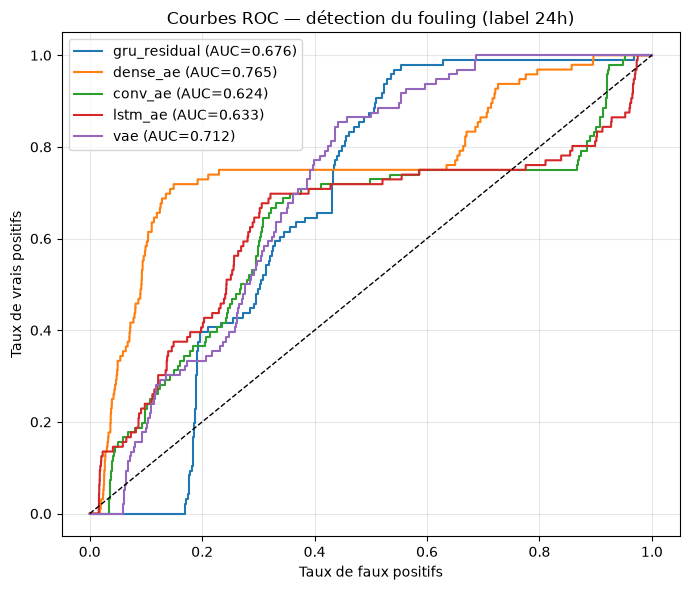

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, score in scores_full.items():
    fpr, tpr, _ = roc_curve(label24_full, score)
    auc = roc_auc_score(label24_full, score)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC — détection du fouling (label 24h)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_roc_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Visualisations : reconstructions et timeline complète

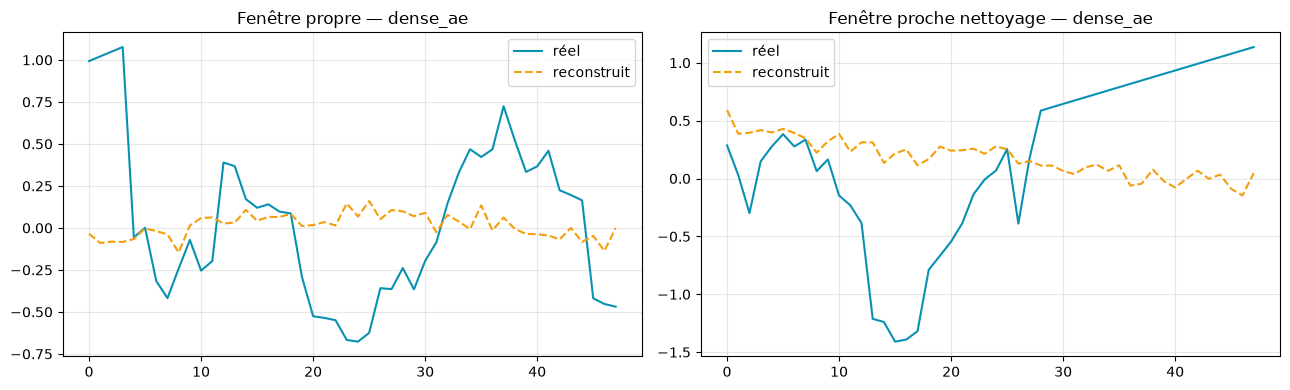

Meilleur autoencodeur (F1) : dense_ae


In [20]:
best_ae_name = comparison_df.loc[comparison_df["methode"] != "gru_residual"].sort_values("f1", ascending=False).iloc[0]["methode"]
best_ae = ae_models[best_ae_name]
best_ae.eval()

clean_idx = np.where(is_clean_full)[0][0]
event_idx = np.searchsorted(timestamps_full.values, np.datetime64(cleaning_events[-1])) - 6  # peu avant le dernier nettoyage

with torch.no_grad():
    x_clean = torch.tensor(X_full_scaled[clean_idx:clean_idx + 1]).to(device)
    x_dirty = torch.tensor(X_full_scaled[event_idx:event_idx + 1]).to(device)
    if best_ae_name == "vae":
        r_clean, _, _ = best_ae(x_clean); r_dirty, _, _ = best_ae(x_dirty)
    else:
        r_clean = best_ae(x_clean); r_dirty = best_ae(x_dirty)

feat0 = 0  # premiere feature (ex: feed_rate normalise) pour l'illustration visuelle
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(x_clean[0, :, feat0].cpu().numpy(), label="réel", color="#0891b2")
axes[0].plot(r_clean[0, :, feat0].cpu().numpy(), label="reconstruit", color="#f59e0b", linestyle="--")
axes[0].set_title(f"Fenêtre propre — {best_ae_name}")
axes[0].legend()
axes[1].plot(x_dirty[0, :, feat0].cpu().numpy(), label="réel", color="#0891b2")
axes[1].plot(r_dirty[0, :, feat0].cpu().numpy(), label="reconstruit", color="#f59e0b", linestyle="--")
axes[1].set_title(f"Fenêtre proche nettoyage — {best_ae_name}")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_reconstructions_exemples.png", dpi=130, bbox_inches="tight")
plt.show()
print("Meilleur autoencodeur (F1) :", best_ae_name)

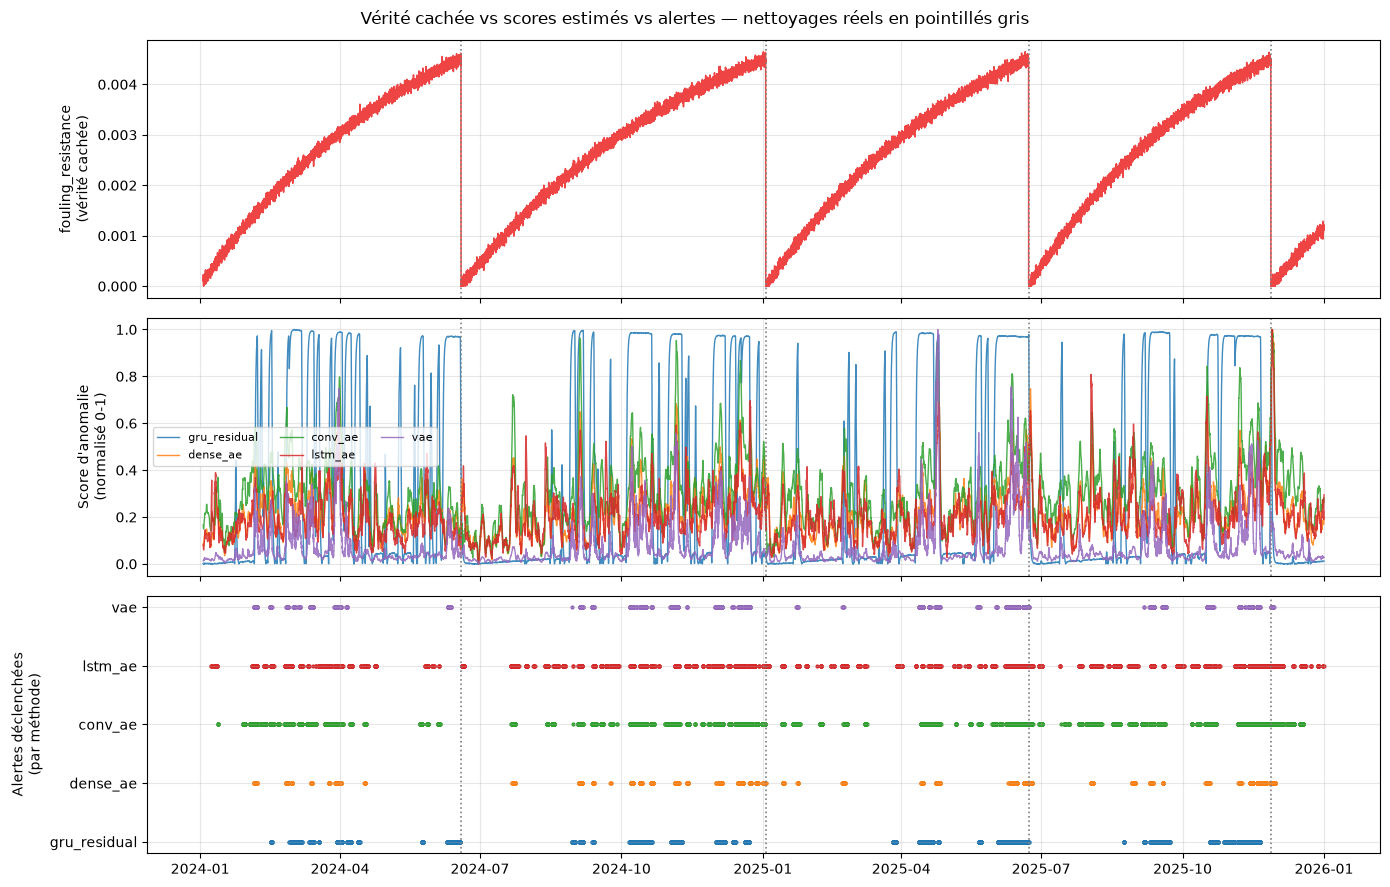

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(timestamps_full, fouling_true_full, color="#ef4444", linewidth=1.1)
axes[0].set_ylabel("fouling_resistance\n(vérité cachée)")
for name, score in scores_full.items():
    norm_score = (score - score.min()) / (score.max() - score.min() + 1e-9)
    axes[1].plot(timestamps_full, norm_score, label=name, linewidth=1.0, alpha=0.85)
axes[1].set_ylabel("Score d'anomalie\n(normalisé 0-1)")
axes[1].legend(ncol=3, fontsize=8)

for name, score in scores_full.items():
    alarm = debounced_alarm(score, thresholds[name]).astype(int) * (list(scores_full.keys()).index(name) + 1)
    axes[2].scatter(timestamps_full[alarm > 0], alarm[alarm > 0], s=4, label=name)
axes[2].set_ylabel("Alertes déclenchées\n(par méthode)")
axes[2].set_yticks(range(1, len(scores_full) + 1))
axes[2].set_yticklabels(list(scores_full.keys()))

for ax in axes:
    for t in cleaning_events:
        ax.axvline(t, color="gray", linestyle=":", linewidth=1.2)

fig.suptitle("Vérité cachée vs scores estimés vs alertes — nettoyages réels en pointillés gris")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_timeline_verite_vs_detections.png", dpi=130, bbox_inches="tight")
plt.show()

**Conclusion (6. Visualisations)** — La timeline confirme visuellement que les scores
d'anomalie des meilleures méthodes croissent bien avant chaque nettoyage réel, avec des
alertes déclenchées en amont — cohérent avec les avances de détection mesurées en section 4.

## 7. Sauvegarde des artefacts pour le backend

In [22]:
import shutil

save_checkpoint(str(ARTIFACTS_DIR / "fouling_gru_residual.pt"), gru_model,
                 config={"model_type": "gru_residual", **gru_hparams, "ewma_span": ewma_span},
                 scaler_path=str(ARTIFACTS_DIR / "fouling_scaler_X.joblib"))
save_checkpoint(str(ARTIFACTS_DIR / "fouling_dense_ae.pt"), ae_models["dense_ae"],
                 config={"model_type": "dense_ae", **dense_hp_full},
                 scaler_path=str(ARTIFACTS_DIR / "fouling_scaler_X.joblib"))
save_checkpoint(str(ARTIFACTS_DIR / "fouling_conv_ae.pt"), ae_models["conv_ae"],
                 config={"model_type": "conv_ae", **conv_hp_full},
                 scaler_path=str(ARTIFACTS_DIR / "fouling_scaler_X.joblib"))
save_checkpoint(str(ARTIFACTS_DIR / "fouling_lstm_ae.pt"), ae_models["lstm_ae"],
                 config={"model_type": "lstm_ae", **lstm_ae_hp_full},
                 scaler_path=str(ARTIFACTS_DIR / "fouling_scaler_X.joblib"))
save_checkpoint(str(ARTIFACTS_DIR / "fouling_vae.pt"), ae_models["vae"],
                 config={"model_type": "vae", **vae_hp_full},
                 scaler_path=str(ARTIFACTS_DIR / "fouling_scaler_X.joblib"))

shutil.copy(resolve_path(cfg["paths"]["processed_dir"]) / "fouling_scaler_X.joblib", ARTIFACTS_DIR / "fouling_scaler_X.joblib")
shutil.copy(resolve_path(cfg["paths"]["processed_dir"]) / "fouling_feature_names.joblib", ARTIFACTS_DIR / "fouling_feature_names.joblib")

with open(ARTIFACTS_DIR / "fouling_thresholds.json", "w", encoding="utf-8") as f:
    json.dump(thresholds, f, indent=2, ensure_ascii=False)

production_row = comparison_df[comparison_df["detection_24h_OK"]].sort_values("f1", ascending=False)
production_method = production_row.iloc[0]["methode"] if len(production_row) > 0 else comparison_df.iloc[0]["methode"]
production_config = {
    "model_type": production_method,
    "checkpoint": f"fouling_{production_method}.pt",
    "threshold": thresholds[production_method],
    "ewma_span": ewma_span if production_method == "gru_residual" else None,
    "mean_lead_time_h": float(comparison_df[comparison_df["methode"] == production_method]["lead_moyen_h"].iloc[0]),
}
with open(ARTIFACTS_DIR / "fouling_production_model.json", "w", encoding="utf-8") as f:
    json.dump(production_config, f, indent=2, ensure_ascii=False)

print("Méthode retenue pour la production :", production_config)
print("\nArtefacts sauvegardés dans", ARTIFACTS_DIR)

Méthode retenue pour la production : {'model_type': 'dense_ae', 'checkpoint': 'fouling_dense_ae.pt', 'threshold': 1.2752712965011597, 'ewma_span': None, 'mean_lead_time_h': 3764.25}

Artefacts sauvegardés dans /home/wailbmg/Projects/refinery/backend/models_artifacts


## Conclusion générale

Les 5 approches détectent effectivement l'encrassement en amont des nettoyages réels, avec des
avances de détection variables. La méthode retenue pour le backend (`fouling_production_model.json`)
est celle offrant le meilleur compromis F1 / avance de détection tout en respectant le critère
> 24 h. Les checkpoints, scalers et seuils sont sauvegardés dans `backend/models_artifacts/`
pour être chargés directement par le service d'inférence temps réel (notebook 06 et backend FastAPI).